In [1]:
"""
Event 1: The sun rises in the east
Event 2: I will learn ML very fast

P ( E1 )=1
P ( E2 )=0.5

Random Events Gives us information rather than sure events, thats why we study randomness that is there is scope of learning for prediction

Data Generating Process : Any entity that generates data

Let say , an original ice cream machine generates the ice cream as follows
Red ice-cream=0.2
Green ice-cream=0.4
Blue ice-cream=0.35
Yellow ice-cream=0.05

My mimicing ice-cream machine:
Red ice-cream=0.21
Green ice-cream=0.38
Blue ice-cream=0.34
Yellow ice-cream=0.07


Population : A set of all samples generated by a data generating process
Sample : A subset of the population of all samples

* Sample must represent the distribution/behaviour of the population

--> 1st portion for training  (Resampling)
--> 2nd portion for testing   ( Resampling)

""";

In [2]:
!pip install ipympl


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib ipympl --upgrade



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
%matplotlib widget
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import entropy

plt.style.use(
   "E:\\BongoDev\\Machine_Learning\\deeplearning.mplstyle\\"
)

In [27]:
np.random.seed(42)
n_samples=100

area=np.random.uniform(500,3000,n_samples)
price=150*area+50000+np.random.normal(0,20000,n_samples)

housing_dataset=pd.DataFrame({
    'area':area,
    'price':price,
}
).round(2)

housing_dataset.head()

,area,price
0,1436.35,267193.49
1,2876.79,475537.72
2,2329.98,401332.94
3,1996.65,309745.55
4,890.05,179113.55


In [28]:
"""
Normalize data
"""
housing_dataset=housing_dataset/housing_dataset.max()

In [29]:
housing_dataset.head()

,area,price
0,0.484073,0.523171
1,0.969524,0.931114
2,0.785240,0.785819
3,0.672903,0.606489
4,0.299961,0.350709


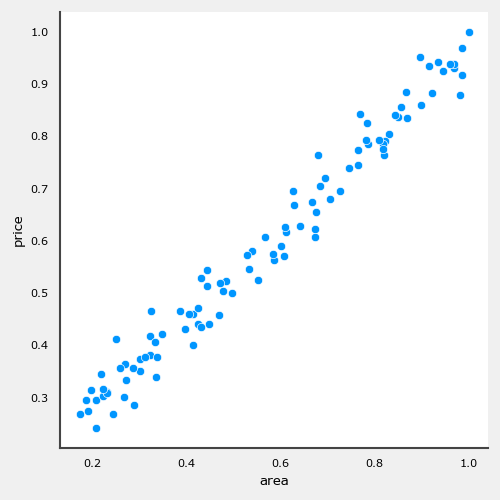

In [30]:
sns.relplot(
    data=housing_dataset,
    x='area',
    y='price',
)
plt.show()

In [31]:
"""
Model
Parameters/Coefficients : weights+bias

"""
def get_house_price(X,w,b):
    y_pred=w*X+b
    return y_pred

In [32]:
# Initializing the parameters of the model
w=np.random.uniform(0,1)
b=np.random.uniform(0,1)
print(w,b)

0.7948113035416484 0.5026370931051921


In [33]:
housing_dataset['price_pred_rand']=get_house_price(housing_dataset['area'],w,b)
housing_dataset.head()

,area,price,price_pred_rand
0,0.484073,0.523171,0.887383
1,0.969524,0.931114,1.273225
2,0.785240,0.785819,1.126755
3,0.672903,0.606489,1.037468
4,0.299961,0.350709,0.741049


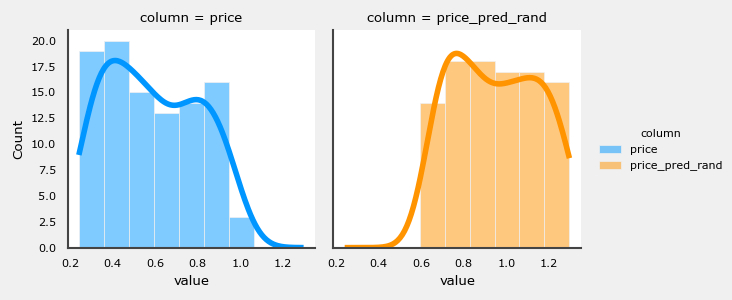

In [34]:
sns.displot(
    data=housing_dataset.melt(value_vars=['price','price_pred_rand'],var_name='column'),
    x='value',
    col='column',
    height=3,

    kind='hist',
    kde=True,
    hue='column',

)

In [35]:
"""
KL Divergence
-Dissimilarities between distributions

Smaller is better . 0 is best that is no dissimilarities
"""
import numpy as np
from scipy.stats import gaussian_kde

def kl_divergence(p_data,q_data,n_points=1000,epsilon=1e-10):
    p_data=np.array(p_data).flatten()
    q_data=np.array(q_data).flatten()
    p_data=p_data[~np.isnan(p_data)]
    q_data=q_data[~np.isnan(q_data)]
    if len(p_data)==0 or len(q_data)==0:
        return np.nan
    all_data=np.concatenate([p_data,q_data])
    support=np.linspace(all_data.min(),all_data.max(),n_points)
    kde_p=gaussian_kde(p_data)
    kde_q=gaussian_kde(q_data)
    p=kde_p(support)
    q=kde_q(support)
    p=np.clip(p,epsilon,None)
    q=np.clip(q,epsilon,None)
    p /= p.sum()
    q /= q.sum()
    kl=np.sum(p*np.log(p/q))
    return kl

kl_value=kl_divergence(housing_dataset['price'],housing_dataset['price_pred_rand'])

print(f"KL(price || price_pred_rand: {kl_value:.4f}")



KL(price || price_pred_rand: 2.8856


In [37]:
"""
Objective of a ML Model
Increase the similarities between the true distribution and the predicted distribution.
Data generating process: Generates data --> True Distribution
ML model tries to mimic the data generating process --> Predicted Distribution

1. Maximize likelihood between true distribution and predicted distribution
2. Alternatively, minimizing the KL divergence
3. Alternatively, minimizing loss/cost function


M.S.E ( Mean Squared Error)
y=10,yhat=12,e1=(y-yhat)^2=4
y = 5, yhat = 6,   e2 = (5-6)^2 = 1
y = 2, yhat = 2, e3 = 0

e=(e1+e2+e3)/3=(4+1+0)/3=5/3
"""

def cost_function(x,y_true,w,b):
    y_pred=get_house_price(x,w,b)
    mse=np.sum((y_true-y_pred)**2)/len(y_true)
    return mse

In [38]:
X=housing_dataset['area']
y_true=housing_dataset['price']

loss=cost_function(X,y_true,w,b)
print(loss)

0.13209874399184798


In [40]:
loss_1=cost_function(X,y_true,w=100,b=125)
print(loss_1)

loss_2 = cost_function(X, y_true, w=124, b=189)
print(loss_2)

loss_3 = cost_function(X, y_true, w=112, b=169)
print(loss_3)

33327.34790611617
67727.82855692986
54430.6965973278


In [42]:
"""
ML model Objective is to reduce loss/cost function
"""
weights=np.linspace(-10,10,100)
biases=np.linspace(-10,10,100)
weights_mesh,bias_mesh=np.meshgrid(weights,biases)

"""
We will produce 10000 points each point : ( w,b,loss)
"""
losses_mesh=[]
for w in tqdm(np.ravel(weights_mesh[0])):
    for b in np.ravel(bias_mesh[0]):
        loss=cost_function(X,y_true,w=w,b=b)
        losses_mesh.append(loss)
losses_mesh=np.array(losses_mesh)
losses_mesh=losses_mesh.reshape(weights_mesh.shape)


100%|██████████| 100/100 [00:02<00:00, 41.11it/s]


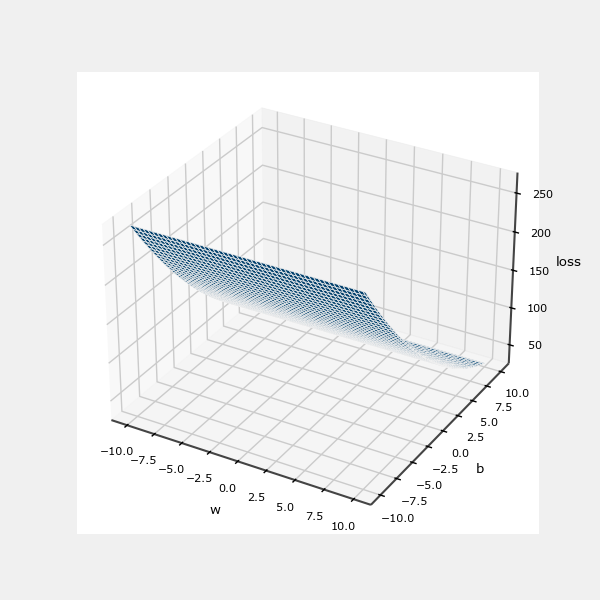

In [43]:
fig=plt.figure(figsize=(6,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(weights_mesh,bias_mesh,losses_mesh)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('loss')
plt.show()